In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'font.size': 14, 'axes.labelsize': 16,
    'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'ytick.right': True, 'xtick.top': True,
    'mathtext.fontset': 'stix',
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})

In [2]:
mask = np.load('bound_mask.npy')
pos = np.load('shell_pos.npy')
vel = np.load('shell_vel.npy')
mass = np.load('shell_mass.npy')
times = np.load('times.npy')
self_PE = np.load('self_PE.npy')
star_mask = np.load('star_mask.npy')

In [3]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 6))

def animate(i):
    ax.clear()
    ax.scatter(pos[i,:, 0][~mask[i]], pos[i,:, 1][~mask[i]], s=2, c='k', alpha=0.25, label='unbound')
    ax.scatter(pos[i,:, 0][mask[i]], pos[i,:, 1][mask[i]], s=1, c='k', label='bound')
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_xlabel('x [kpc]')
    ax.set_ylabel('y [kpc]')
    ax.set_title(f't = {times[i]:.0f} Myr')
    ax.legend(loc='upper right', markerscale=5)

anim = FuncAnimation(fig, animate, frames=len(times), interval=500)
plt.close(fig)
HTML(anim.to_jshtml())

In [4]:
# Assign stars as the 10% most bound particles at the first snapshot
center_vel = np.mean(vel[0], axis=0)
binding = self_PE[0] + 0.5 * mass* np.sum((vel[0] - center_vel)**2, axis=1)

In [5]:
sorted_binding_indices = np.argsort(binding)
star_mask = sorted_binding_indices[:int(0.1*len(binding))]

Text(0, 0.5, 'y [kpc]')

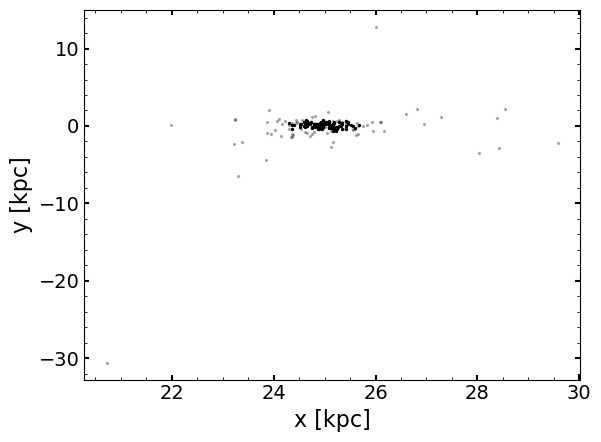

In [4]:
plt.scatter(pos[0, :, 0][star_mask], pos[0, :, 1][star_mask], s=2, c='k', label='stars')
plt.scatter(pos[0, :, 0][~star_mask], pos[0, :, 1][~star_mask], s=2, c='k', alpha=0.25, label='other particles')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

In [5]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 6))

def animate(i):
    ax.clear()
    ax.scatter(pos[i,:, 0][~star_mask], pos[i,:, 1][~star_mask], s=2, c='k', alpha=0.25, label='DM')
    ax.scatter(pos[i,:, 0][star_mask], pos[i,:, 1][star_mask], s=1, c='k', label='stars')
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_xlabel('x [kpc]')
    ax.set_ylabel('y [kpc]')
    ax.set_title(f't = {times[i]:.0f} Myr')
    ax.legend(loc='upper right', markerscale=5)

anim = FuncAnimation(fig, animate, frames=len(times), interval=500)
plt.close(fig)
HTML(anim.to_jshtml())

In [6]:
### STARS ONLY ####
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 6))

def animate(i):
    ax.clear()
    ax.scatter(pos[i,:, 0][star_mask], pos[i,:, 1][star_mask], s=1, c='k')
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_xlabel('x [kpc]')
    ax.set_ylabel('y [kpc]')
    ax.set_title(f't = {times[i]:.0f} Myr')

anim = FuncAnimation(fig, animate, frames=len(times), interval=500)
plt.close(fig)
HTML(anim.to_jshtml())